# U.S. Interstate Migration Analysis

**Author:** Laxminarayan Sahu  
**Program:** IBM SkillsBuild Data Analytics with AI Academic Internship Program  
**Conducted by:** BharatCares in association with AICTE

This complete notebook classifies past-year interstate moves in IPUMS CPS ASEC records. It cleans the data, compares models, evaluates a temporal holdout, generates diagnostics, and exports results. All model code and state names are included here.

## Data and setup
Install `requirements.txt` in the notebook environment. Request the IPUMS CPS extract at https://cps.ipums.org/ and include YEAR, ASECFLAG, STATEFIP, AGE, SEX, RACE, EDUC, INCTOT, MIGRATE1, ASECWT, and CPSIDP for 2010–2019. Save it as `data/cps_00001.csv` next to this notebook. IPUMS registration is required; the raw extract is not redistributed.

Use **Kernel → Restart Kernel and Run All Cells**. Outputs will be written to `results/`.

## Research design

The target is `MIGRATE1 == 5`. Codes 1, 3, and 4 are negatives; codes for foreign moves, unknown location, and non-universe responses are excluded. Adults in the ASEC supplement with positive survey weight are eligible.

Training uses 2010–2015; validation uses 2016–2017; testing uses 2018–2019. Earlier records linked to respondents in later partitions are removed. Preprocessing is fitted on training data, and model/threshold selection uses validation only. ASECWT weights fitting and state summaries; the primary evaluation is unweighted.

The features are age, squared age, signed log personal income, current state, sex, race, and education. State outcome aggregates are excluded. This retrospective study does not establish future migration or causal policy effects.

In [ ]:
"""Reproducible retrospective interstate-migration classification.

Run this file or the original named entry point. Never uses outcome aggregates
as predictors. Hyperparameters and decision threshold use validation years only.
"""
from pathlib import Path
import argparse
import json
import time
import platform
import hashlib
import shutil

import joblib
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, brier_score_loss, log_loss,
    precision_recall_curve, confusion_matrix, roc_curve)
from threadpoolctl import threadpool_limits

ROOT = Path.cwd()
NUMERIC = ['AGE', 'LOG_INCOME', 'AGE_SQUARED']
CATEGORICAL = ['STATEFIP', 'SEX', 'RACE', 'EDUC']
FEATURES = NUMERIC + CATEGORICAL
STATE_NAMES = {1: 'Alabama', 2: 'Alaska', 4: 'Arizona', 5: 'Arkansas', 6: 'California', 8: 'Colorado', 9: 'Connecticut', 10: 'Delaware', 11: 'District of Columbia', 12: 'Florida', 13: 'Georgia', 15: 'Hawaii', 16: 'Idaho', 17: 'Illinois', 18: 'Indiana', 19: 'Iowa', 20: 'Kansas', 21: 'Kentucky', 22: 'Louisiana', 23: 'Maine', 24: 'Maryland', 25: 'Massachusetts', 26: 'Michigan', 27: 'Minnesota', 28: 'Mississippi', 29: 'Missouri', 30: 'Montana', 31: 'Nebraska', 32: 'Nevada', 33: 'New Hampshire', 34: 'New Jersey', 35: 'New Mexico', 36: 'New York', 37: 'North Carolina', 38: 'North Dakota', 39: 'Ohio', 40: 'Oklahoma', 41: 'Oregon', 42: 'Pennsylvania', 44: 'Rhode Island', 45: 'South Carolina', 46: 'South Dakota', 47: 'Tennessee', 48: 'Texas', 49: 'Utah', 50: 'Vermont', 51: 'Virginia', 53: 'Washington', 54: 'West Virginia', 55: 'Wisconsin', 56: 'Wyoming'}


def clean_records(frame):
    """CPS MIGRATE1: 3 within county, 4 within state, 5 between states."""
    keep = (frame.YEAR.between(2010, 2019) & frame.ASECFLAG.eq(1)
            & frame.AGE.ge(18) & frame.MIGRATE1.isin([1, 3, 4, 5])
            & frame.STATEFIP.isin(STATE_NAMES) & frame.ASECWT.gt(0))
    d = frame.loc[keep].copy()
    d['MIGRATED'] = d.MIGRATE1.eq(5).astype('int8')
    d['INCOME_CLEAN'] = d.INCTOT.replace([999999998, 999999999], np.nan)
    d['LOG_INCOME'] = np.sign(d.INCOME_CLEAN) * np.log1p(d.INCOME_CLEAN.abs())
    d['AGE_SQUARED'] = d.AGE.astype(float) ** 2
    d['STATE_NAME'] = d.STATEFIP.map(STATE_NAMES)
    return d


def temporal_split(d):
    train = d[d.YEAR.le(2015)].copy()
    valid = d[d.YEAR.between(2016, 2017)].copy()
    test = d[d.YEAR.ge(2018)].copy()
    # CPS follows some people across years. Keep the latest partition and purge
    # earlier matches. Zero denotes an unavailable longitudinal identifier.
    test_ids = set(test.loc[test.CPSIDP.gt(0), 'CPSIDP'])
    valid = valid[~valid.CPSIDP.isin(test_ids)]
    later_ids = test_ids | set(valid.loc[valid.CPSIDP.gt(0), 'CPSIDP'])
    train = train[~train.CPSIDP.isin(later_ids)]
    return train, valid, test


def make_model(kind, leaves=15):
    numeric = Pipeline([('impute', SimpleImputer(strategy='median', add_indicator=True)),
                        ('scale', StandardScaler())])
    if kind == 'logistic':
        categories = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        estimator = LogisticRegression(C=1, max_iter=600, random_state=42)
    else:
        categories = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        # Numerical imputation can add columns; explicit transformed mask is set
        # after fitting preprocessing below, so category codes are never ordinal.
        estimator = HistGradientBoostingClassifier(max_iter=180, learning_rate=.06,
            max_leaf_nodes=leaves, min_samples_leaf=100, l2_regularization=10,
            early_stopping=False, random_state=42)
    prep = ColumnTransformer([('numeric', numeric, NUMERIC),
                              ('categorical', categories, CATEGORICAL)])
    return Pipeline([('prep', prep), ('model', estimator)])


def fit_model(model, train):
    x = model['prep'].fit_transform(train[FEATURES])
    if isinstance(model['model'], HistGradientBoostingClassifier):
        model['model'].set_params(categorical_features=[False] * (x.shape[1] - len(CATEGORICAL))
                                 + [True] * len(CATEGORICAL))
    model['model'].fit(x, train.MIGRATED, sample_weight=train.ASECWT / train.ASECWT.mean())
    return model


def select_threshold(y, probability):
    precision, recall, thresholds = precision_recall_curve(y, probability)
    f1 = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-15)
    return float(thresholds[np.argmax(f1)])


def evaluate(y, p, threshold, weights=None):
    predicted = p >= threshold
    return {'roc_auc': float(roc_auc_score(y, p, sample_weight=weights)),
            'average_precision': float(average_precision_score(y, p, sample_weight=weights)),
            'accuracy': float(accuracy_score(y, predicted, sample_weight=weights)),
            'precision': float(precision_score(y, predicted, sample_weight=weights, zero_division=0)),
            'recall': float(recall_score(y, predicted, sample_weight=weights, zero_division=0)),
            'f1': float(f1_score(y, predicted, sample_weight=weights, zero_division=0)),
            'brier': float(brier_score_loss(y, p, sample_weight=weights)),
            'log_loss': float(log_loss(y, p, sample_weight=weights)),
            'observed_rate': float(np.average(y, weights=weights)),
            'mean_probability': float(np.average(p, weights=weights)),
            'confusion_matrix': confusion_matrix(y, predicted, sample_weight=weights).tolist()}


def plot_results(test, p, baseline_p, metrics, state, out):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    from sklearn.calibration import calibration_curve
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    for label, values in [('Logistic baseline', baseline_p), ('Selected model', p)]:
        fpr, tpr, _ = roc_curve(test.MIGRATED, values)
        axes[0].plot(fpr, tpr, label=f'{label}: {roc_auc_score(test.MIGRATED, values):.3f}')
        pr, re, _ = precision_recall_curve(test.MIGRATED, values)
        axes[1].plot(re, pr, label=label)
        observed, predicted = calibration_curve(test.MIGRATED, values, n_bins=10, strategy='quantile')
        axes[2].plot(predicted, observed, 'o-', label=label)
    axes[0].plot([0, 1], [0, 1], '--', color='gray')
    axes[1].axhline(test.MIGRATED.mean(), linestyle='--', color='gray', label='Prevalence')
    axes[2].plot([0, .15], [0, .15], '--', color='gray')
    for ax, title, x, y in zip(axes, ['ROC', 'Precision–recall', 'Calibration'],
                             ['False positive rate', 'Recall', 'Mean estimated probability'],
                             ['True positive rate', 'Precision', 'Observed rate']):
        ax.set(title=title, xlabel=x, ylabel=y)
        ax.legend(fontsize=8)
        ax.grid(alpha=.2)
    fig.suptitle('2018–2019 holdout • retrospective interstate migration • unweighted metrics')
    fig.tight_layout()
    fig.savefig(out / 'model_evaluation.png', dpi=150)
    plt.close(fig)
    fig, ax = plt.subplots(figsize=(10, 7))
    top = state.head(20).iloc[::-1]
    ax.barh(top.STATE_NAME, top.avg_risk_score * 100, label='Estimated')
    ax.scatter(top.actual_migration_rate * 100, top.STATE_NAME, color='orange', label='Observed', zorder=3)
    ax.set(xlabel='Interstate migration (%)', title='Residents by current state • survey-weighted holdout')
    ax.legend()
    fig.tight_layout()
    fig.savefig(out / 'state_risk_rankings.png', dpi=150)
    plt.close(fig)


def run(data_path=ROOT / 'data' / 'cps_00001.csv', output=ROOT / 'data', sync_frontend=True):
    start = time.perf_counter()
    output = Path(output)
    output.mkdir(parents=True, exist_ok=True)
    columns = ['YEAR', 'ASECFLAG', 'STATEFIP', 'AGE', 'SEX', 'RACE', 'EDUC',
               'INCTOT', 'MIGRATE1', 'ASECWT', 'CPSIDP']
    print('Loading and cleaning CPS records...', flush=True)
    chunks = [clean_records(c) for c in pd.read_csv(data_path, usecols=columns, chunksize=400000)]
    d = pd.concat(chunks, ignore_index=True)
    del chunks
    train, valid, test = temporal_split(d)
    print(f'Eligible={len(d):,}; train={len(train):,}; validation={len(valid):,}; test={len(test):,}', flush=True)
    if any(s.MIGRATED.nunique() != 2 for s in (train, valid, test)):
        raise ValueError('Each temporal split must contain both outcome classes.')
    candidates = {}
    fitted = {}
    with threadpool_limits(limits=4):
        for name, kind, leaves in [('logistic', 'logistic', 15), ('boosting_15', 'boosting', 15),
                                   ('boosting_31', 'boosting', 31)]:
            tick = time.perf_counter()
            print(f'Training {name}...', flush=True)
            model = fit_model(make_model(kind, leaves), train)
            vp = model.predict_proba(valid[FEATURES])[:, 1]
            threshold = select_threshold(valid.MIGRATED, vp)
            candidates[name] = {'validation': evaluate(valid.MIGRATED, vp, threshold),
                                'threshold': threshold, 'seconds': time.perf_counter() - tick}
            fitted[name] = model
            print(json.dumps({'name': name, **candidates[name]}), flush=True)
        winner = max(candidates, key=lambda n: candidates[n]['validation']['average_precision'])
        model = fitted[winner]
        threshold = candidates[winner]['threshold']
        # Test labels first used after all selection decisions are frozen.
        p = model.predict_proba(test[FEATURES])[:, 1]
        base_p = fitted['logistic'].predict_proba(test[FEATURES])[:, 1]
        metrics = evaluate(test.MIGRATED, p, threshold)
        baseline = evaluate(test.MIGRATED, base_p, candidates['logistic']['threshold'])
        null_p = np.full(len(test), np.average(train.MIGRATED, weights=train.ASECWT))
        null = evaluate(test.MIGRATED, null_p, .5)
    result = test[['YEAR', 'STATE_NAME', 'AGE', 'INCOME_CLEAN', 'ASECWT', 'MIGRATED']].copy()
    result['RISK_SCORE'] = p
    result['PREDICTED'] = (p >= threshold).astype(int)
    # These are relative screening bands, not confidence intervals or policy cutoffs.
    result['RISK_CATEGORY'] = np.where(p >= threshold, 'High Risk',
                                       np.where(p >= threshold / 2, 'Medium Risk', 'Low Risk'))
    rows = []
    for name, g in result.groupby('STATE_NAME'):
        rows.append({'STATE_NAME': name, 'avg_risk_score': np.average(g.RISK_SCORE, weights=g.ASECWT),
                     'actual_migration_rate': np.average(g.MIGRATED, weights=g.ASECWT),
                     'high_risk_pct': np.average(g.PREDICTED, weights=g.ASECWT), 'n_individuals': len(g)})
    state = pd.DataFrame(rows).sort_values('avg_risk_score', ascending=False)
    report = {'selected_model': winner, 'selection_metric': 'validation average precision (unweighted)',
              'decision_threshold': threshold, 'candidates': candidates, 'test': metrics,
              'test_survey_weighted': evaluate(test.MIGRATED, p, threshold, test.ASECWT),
              'logistic_baseline_test': baseline, 'no_skill_test': null,
              'splits': {name: {'rows': len(s), 'years': sorted(s.YEAR.unique().tolist()),
                  'positive_count': int(s.MIGRATED.sum()), 'unknown_person_ids': int(s.CPSIDP.eq(0).sum())}
                  for name, s in [('train', train), ('validation', valid), ('test', test)]},
              'purged_earlier_records': len(d) - len(train) - len(valid) - len(test),
              'features': FEATURES, 'target': 'MIGRATE1 == 5; codes 1,3,4 are negative',
              'interpretation': 'Past-year interstate moves among current residents; not future outflow.',
              'risk_bands': {'medium_min': threshold / 2, 'high_min': threshold},
              'weighting': 'ASECWT for training and state aggregates; primary selection/metrics unweighted.',
              'per_year_test': {str(y): evaluate(test.loc[test.YEAR.eq(y), 'MIGRATED'], p[test.YEAR.eq(y)], threshold)
                                for y in sorted(test.YEAR.unique())},
              'versions': {'python': platform.python_version(), 'pandas': pd.__version__, 'sklearn': sklearn.__version__},
              'source_file': {'name': Path(data_path).name, 'bytes': Path(data_path).stat().st_size},
              'runtime_seconds': time.perf_counter() - start}
    summary = {'total_records': len(d), 'total_states': len(state), 'year_range': '2010-2019',
               'overall_migration_rate': float(np.average(d.MIGRATED, weights=d.ASECWT)),
               **{f'model_{k}': metrics[k] for k in ['accuracy', 'precision', 'recall', 'f1']},
               'model_auc': metrics['roc_auc'], 'model_average_precision': metrics['average_precision'],
               'model_brier': metrics['brier'], 'model_name': winner, 'test_records': len(test),
               'decision_threshold': threshold, 'highest_risk_state': state.iloc[0].STATE_NAME,
               'highest_risk_score': float(state.iloc[0].avg_risk_score),
               'interpretation': report['interpretation'], 'risk_bands': report['risk_bands']}
    state.to_csv(output / 'state_risk_scores.csv', index=False)
    result.sample(n=min(2000, len(result)), random_state=42).drop(columns='ASECWT').to_csv(output / 'individual_predictions.csv', index=False)
    for name, value in [('evaluation_report.json', report), ('eda_summary.json', summary)]:
        (output / name).write_text(json.dumps(value, indent=2, allow_nan=False), encoding='utf-8')
    joblib.dump({'pipeline': model, 'features': FEATURES, 'threshold': threshold,
                 'risk_bands': report['risk_bands'], 'versions': report['versions']}, output / 'migration_model.joblib')
    plot_results(test, p, base_p, metrics, state, output)
    if sync_frontend:
        public = ROOT / 'frontend' / 'public' / 'data'
        public.mkdir(parents=True, exist_ok=True)
        for name in ['state_risk_scores.csv', 'individual_predictions.csv', 'eda_summary.json',
                     'evaluation_report.json', 'model_evaluation.png', 'state_risk_rankings.png']:
            shutil.copy2(output / name, public / name)
    print(json.dumps({'winner': winner, 'test': metrics, 'baseline': baseline}, indent=2), flush=True)
    return report


def main():
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument('--data', type=Path, default=ROOT / 'data' / 'cps_00001.csv')
    parser.add_argument('--output', type=Path, default=ROOT / 'data')
    parser.add_argument('--no-sync-frontend', action='store_true')
    args = parser.parse_args()
    run(args.data, args.output, not args.no_sync_frontend)





In [ ]:
# Locate the dataset next to this notebook or in a parent project folder.
DATA = next((p / 'data' / 'cps_00001.csv' for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data' / 'cps_00001.csv').is_file()), None)
if DATA is None:
    raise FileNotFoundError('Download the IPUMS extract and place it at data/cps_00001.csv.')
report = run(DATA, Path.cwd() / 'results', sync_frontend=False)


## Verified reference run

The following stored results and figures come from the full project run. The training cell above reruns the same workflow using your dataset. Exact reproduction requires the same extract and package versions; the stored run used Python 3.12.7, pandas 3.0.2, and scikit-learn 1.9.0.

In [ ]:
# Inspect the results of the current run.
print(json.dumps(report['test'], indent=2))

{
  "roc_auc": 0.6993579410450982,
  "average_precision": 0.0474775753137442,
  "accuracy": 0.9516528941261976,
  "precision": 0.0646908231587239,
  "recall": 0.16717557251908396,
  "f1": 0.09328411188414028,
  "brier": 0.014473095939154787,
  "log_loss": 0.07332215976765946,
  "observed_rate": 0.014876614945509193,
  "mean_probability": 0.017099921391453277,
  "confusion_matrix": [
    [
      250744,
      9499
    ],
    [
      3273,
      657
    ]
  ]
}


## Model diagnostics

ROC measures ranking across thresholds; precision–recall is useful for the rare positive class. The reliability diagram checks agreement between estimated probabilities and observed rates. No separate post-hoc calibration model is fitted.

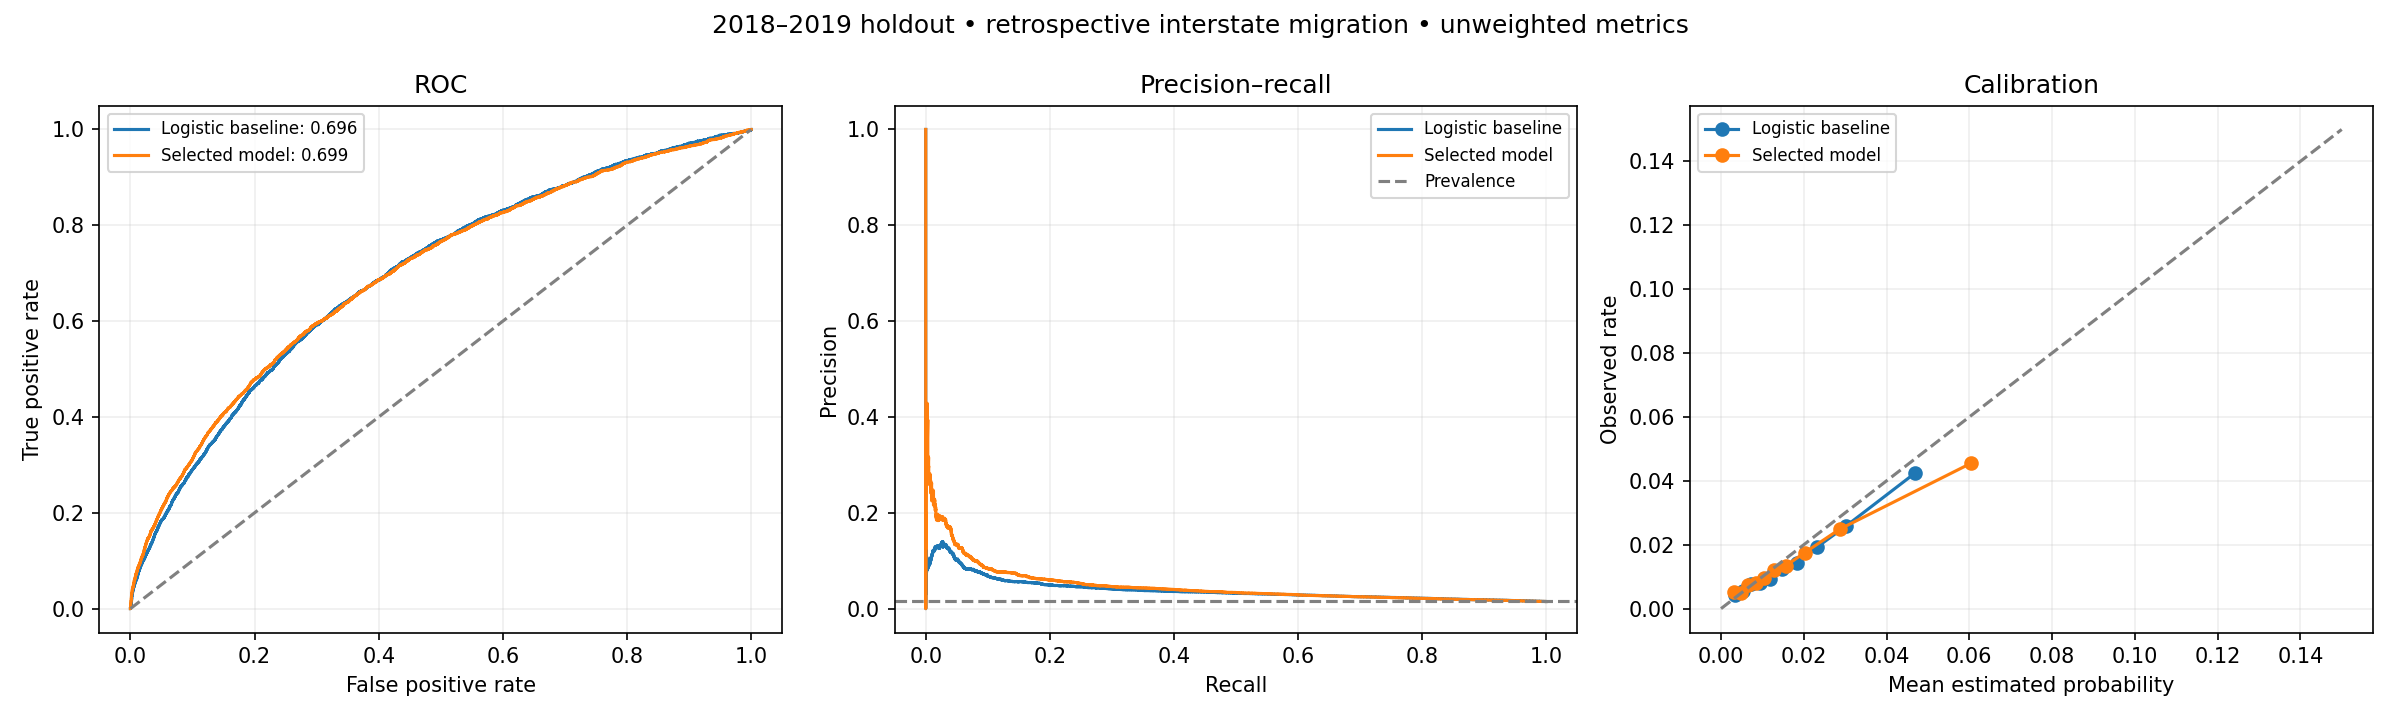

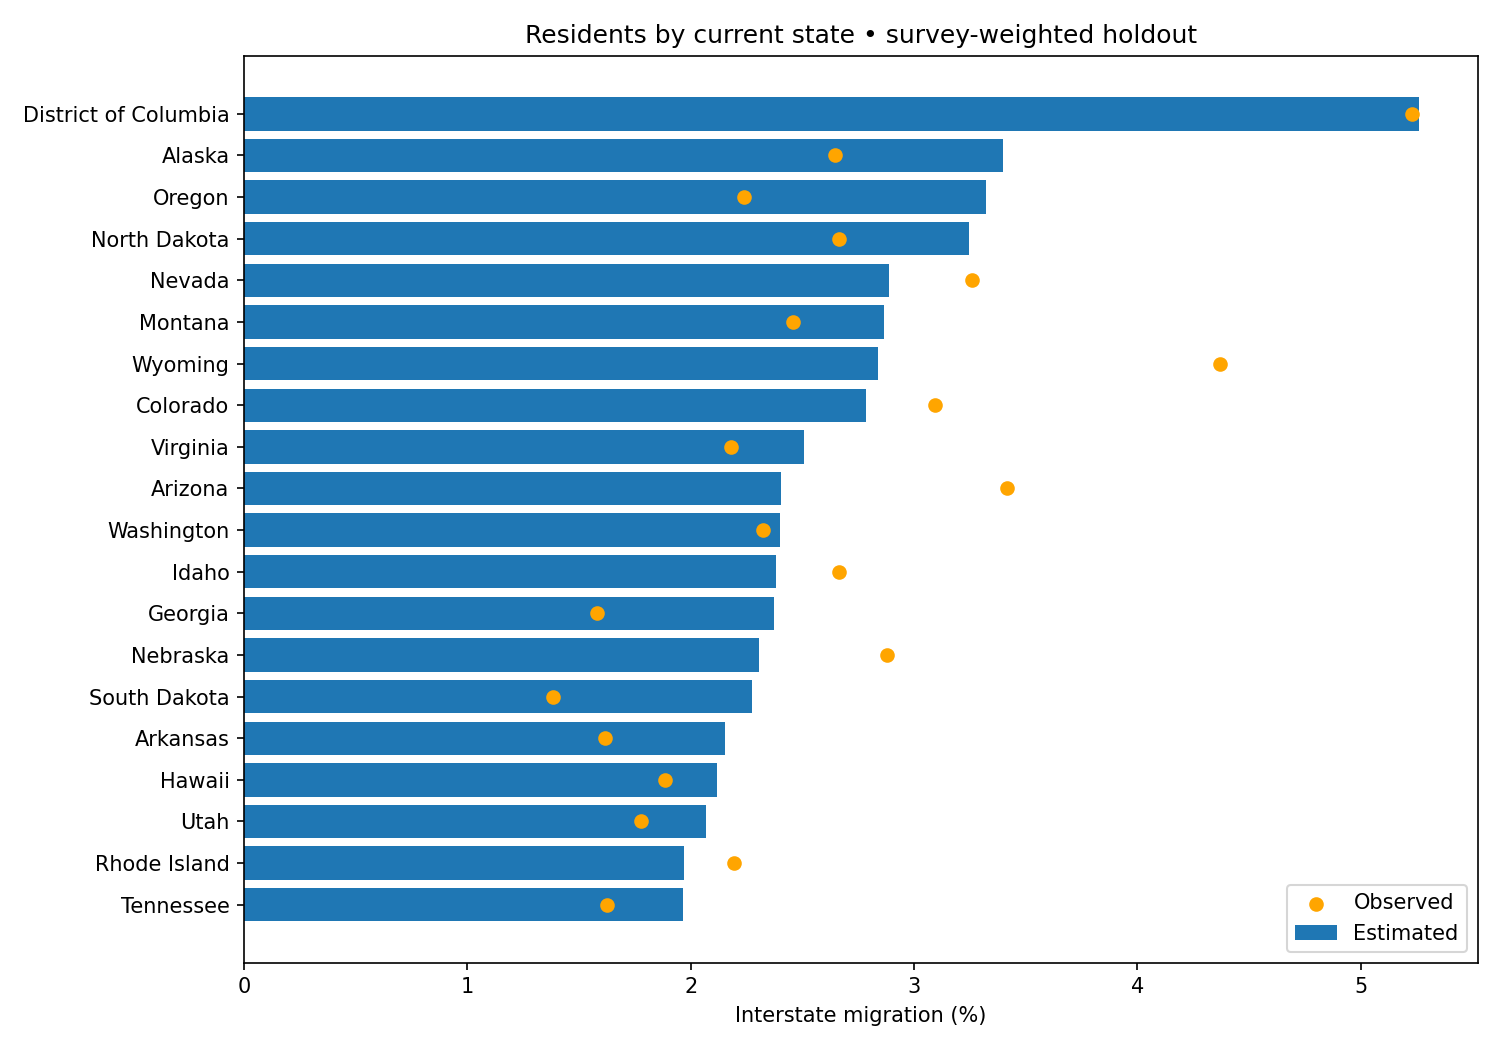

## Conclusions and limitations

The selected 31-leaf histogram gradient-boosting model achieved ROC-AUC 0.6994 and average precision 0.04748 on 264,173 holdout records, compared with logistic regression values of 0.6960 and 0.03919. At the validation-selected threshold of 5.595%, precision is 6.47% and recall is 16.72%. Many flagged observations are false positives.

A classifier that predicts no moves achieves 98.51% accuracy because the target rate is 1.49%; the selected model has 95.17% accuracy but useful ranking information. Accuracy should not be presented as the main performance claim. Current state identifies the destination residence, so these aggregates do not estimate departure risk from an origin state. Demographic predictors include sensitive attributes and require fairness analysis before any consequential use. Inflation adjustment and survey-design uncertainty estimation are further work.

## References
- IPUMS CPS MIGRATE1: https://cps.ipums.org/cps-action/variables/MIGRATE1
- IPUMS CPS INCTOT: https://cps.ipums.org/cps-action/variables/INCTOT
- CPS ASEC survey weight: https://cps.ipums.org/cps-action/variables/ASECWT
- Census historical context: https://www.census.gov/data/tables/time-series/demo/geographic-mobility/state-to-state-migration.html
